# Attribute Presence via Semantic Similarity

Semantic similarity (cosine distance) between the reviews and the attribute (keywords and part from groundtruth reviews containing the attribute)




In [38]:
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, recall_score, confusion_matrix
import numpy as np
import seaborn as sns

### Model choice: sentence-transformers/all-mpnet-base-v2

- Embedding dimension: 764 (can understand nuances)
- Max input tokens: 384 (more than enough for the reviews)
- Very fast (even on a small laptop)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", cache_folder='../../embedding_models').to(device)

In [ ]:
from langdetect import detect, DetectorFactory, LangDetectException

# Ensure consistent language detection results
DetectorFactory.seed = 0

def safe_detect(text):
    if not isinstance(text, str):
        return "unknown"
    
    # FIX: If text is very short, just assume English (or your main language)
    if len(text) < 15:
        return "en"
        
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

def clean_data(df, review_col):

    df[review_col] = df[review_col].fillna("").astype(str)

    df['ID'] = df.index.astype(int)
    df['ID'] += 1  # Start IDs from 1 instead of 0

    df['lang'] = df[review_col].apply(safe_detect)

    return df

### Load data

In [ ]:
df_4 = pd.read_excel('../../data/initial_data/Study 4 reviews.xlsx')
df_4 = clean_data(df_4, "text")

df_4.columns

reviews = df_4["text"].fillna("").tolist() 
reviews[:5]

['Not so good', 'Decent', 'Could be better', 'Alright', 'OK']

### Reviews and Groundtruth embedding

For the groundtruth, I tried with only the name of the attributes, with description of the attributes or with relevant part of reviews/keywords.
The last approach is the one that works best.

NOTE: keywords and sample from reviews after the first 100, and then validation on the first 100, so no leakage

In [42]:
attribute_names = [
    'Quality_and_taste_of_food',
    'Cleanliness',
    'Friendliness_of_staff',
    'Value',
    'Speed_of_service'
]

reviews_example = [
    "The coffee was better, Very good food there and drinks",
    'Cleanliness',
    'needs better people, Unfriendly staff, behavior, I called her and no help, Did she hear me? polite',
    'Cheap, expensive, value for money',
    'No waiting, Left me standing there, For how long should I stand there? Had to wait ten minutes'
]

review_embeddings = model.encode(reviews, convert_to_tensor=True, show_progress_bar=True)
attr_embeddings = model.encode(reviews_example, convert_to_tensor=True)


Batches: 100%|██████████| 20/20 [00:00<00:00, 202.96it/s]


### Evaluation on the first 100 reviews

We use the AUC to evaluate the method and the groundtruth choice

/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


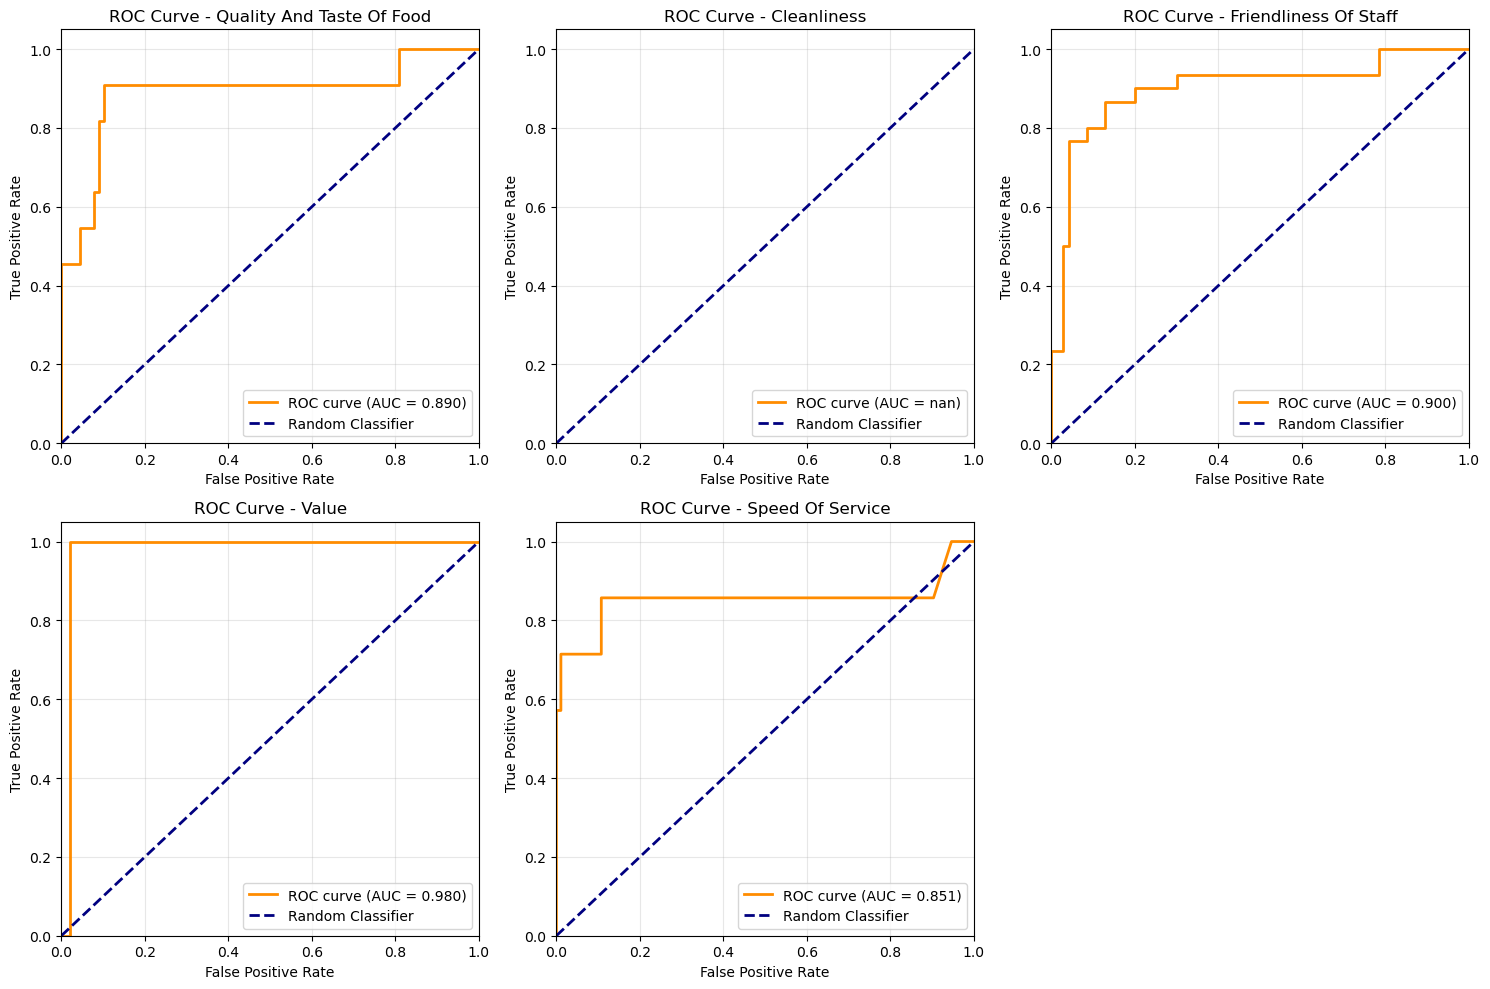


AUC Scores for Each Attribute:
Quality And Taste Of Food                AUC = 0.8897
Cleanliness                              AUC = nan
Friendliness Of Staff                    AUC = 0.9005
Value                                    AUC = 0.9798
Speed Of Service                         AUC = 0.8510


/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [43]:
valid_df = pd.read_csv('../data/labeled_presence/label_Study_4_reviews.csv')
valid_df = valid_df.iloc[:100,:] # Validation on the last 100 (hand-labeled)

valid_review_embeddings = model.encode(
    valid_df["text"].fillna("").tolist(), 
    convert_to_tensor=True
)
valid_cosine_scores = util.cos_sim(valid_review_embeddings, attr_embeddings)
valid_scores = valid_cosine_scores.cpu().numpy()

# Plot ROC curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve - {attr_name.replace("_", " ").title()}')
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

# Remove the extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('roc_curves_all_attributes.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print("\n" + "="*60)
print("AUC Scores for Each Attribute:")
print("="*60)
for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    roc_auc = roc_auc_score(y_true, y_scores)
    print(f"{attr_name.replace('_', ' ').title():<40} AUC = {roc_auc:.4f}")

### Get the optimal selection threshold

In [44]:
print("\n" + "="*60)
print("Optimal Thresholds (Youden's J statistic):")
print("="*60)

optimal_thresholds = []

for i, attr_name in enumerate(attribute_names):
    y_true = valid_df[attr_name].astype(int).values
    y_scores = valid_scores[:, i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Youden's J statistic: maximize (TPR - FPR)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    optimal_thresholds.append(optimal_threshold)
    
    print(f"{attr_name.replace('_', ' ').title():<40} Threshold = {optimal_threshold:.4f}")


Optimal Thresholds (Youden's J statistic):
Quality And Taste Of Food                Threshold = 0.1929
Cleanliness                              Threshold = inf
Friendliness Of Staff                    Threshold = 0.1437
Value                                    Threshold = 0.3626
Speed Of Service                         Threshold = 0.2163


/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [45]:
cosine_scores = util.cos_sim(review_embeddings, attr_embeddings)
cosine_scores_np = cosine_scores.cpu().numpy()

predictions = np.zeros_like(cosine_scores_np, dtype=int)
# Use the optimal thresolds obtained above
for i, threshold in enumerate(optimal_thresholds):
    predictions[:, i] = (cosine_scores_np[:, i] > threshold).astype(int)

for i, attr_name in enumerate(attribute_names):
    col_name = f"pred_{attr_name.replace(' ', '_')}"
    df_1[col_name] = predictions[:, i]

df_1.head()

,ID,text,Satisfaction_RA2,Quality_and_taste_of_food,Cleanliness,Friendliness_of_staff,Value,Speed_of_service,Quality_and_taste_of_food_sentiment,Cleanliness_sentiment,Friendliness_of_staff_sentiment,Value_sentiment,Speed_of_service_sentiment,Emotional_intensity_LLM,lang,pred_Quality_and_taste_of_food,pred_Cleanliness,pred_Friendliness_of_staff,pred_Value,pred_Speed_of_service
0,1,Not so good,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,0,0,0,0,0
1,2,Decent,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,0,0,1,0,0
2,3,Could be better,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,1,0,0,0,0
3,4,Alright,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,0,0,0,0,0
4,5,OK,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en,0,0,0,0,0


Percentage reviews well classified for all attributes:
 - Overall: 0.6600

Accuracy Scores per Attribute:
 - Quality_and_taste_of_food: 0.9000
 - Cleanliness: 1.0000
 - Friendliness_of_staff: 0.8600
 - Value: 0.9700
 - Speed_of_service: 0.8800
Recall Scores per Attribute:
 - Quality_and_taste_of_food: 0.9091
 - Cleanliness: 0.0000
 - Friendliness_of_staff: 0.8333
 - Value: 0.0000
 - Speed_of_service: 0.7143


/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


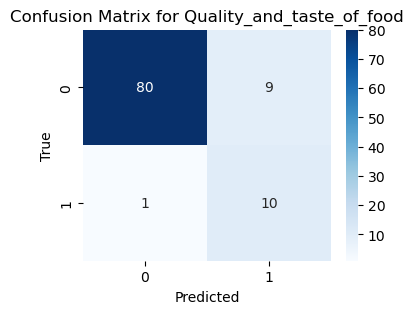

/users/eleves-a/2022/adrien.bindel/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


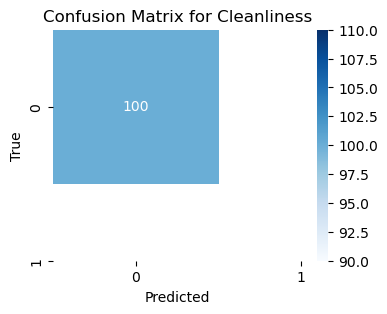

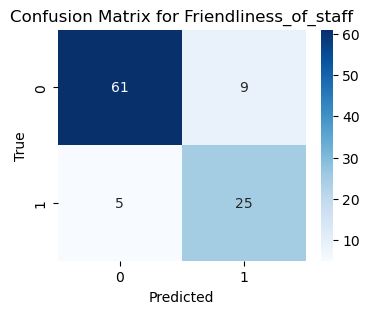

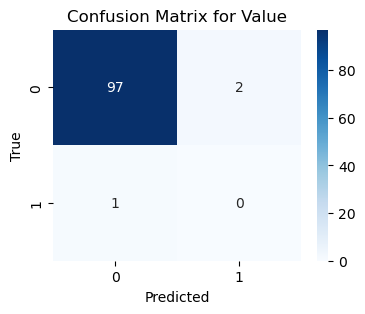

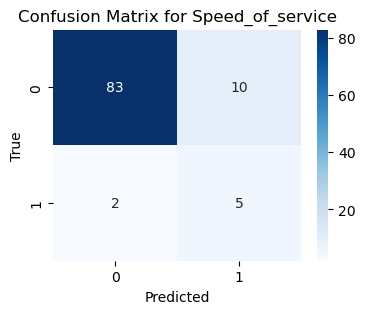

In [46]:
predicted_column_names = [f"pred_{attr.replace(' ', '_')}" for attr in attribute_names]
pred_df =  df_1.iloc[:100,:]

accuracy_scores = {}
recall_scores = {}
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[f"pred_{attr_name}"].astype(int).tolist()[:len(y_true)]
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy_scores[attr_name] = accuracy
    recall_scores[attr_name] = recall

print("Percentage reviews well classified for all attributes:")
well_classified = (pred_df[predicted_column_names].astype(int).values == valid_df[attribute_names].astype(int).values).all(axis=1).mean()
print(f" - Overall: {well_classified:.4f}\n")

print("Accuracy Scores per Attribute:")
for attr_name, score in accuracy_scores.items():
    print(f" - {attr_name}: {score:.4f}")

print("Recall Scores per Attribute:")
for attr_name, score in recall_scores.items():
    print(f" - {attr_name}: {score:.4f}")

# create a confusion matrix for each attribute
for attr_name in attribute_names:
    y_true = valid_df[attr_name].astype(int).tolist()
    y_pred = pred_df[f"pred_{attr_name}"].astype(int).tolist()[:len(y_true)]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'Confusion Matrix for {attr_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
